In [ ]:
# Compare benchmark-FATES difference

In [1]:
import numpy as np
from scipy import stats
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
import shapefile
from shapely.geometry import shape
import shapely.vectorized
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
#
import shapefile
import shapely
from shapely.geometry import shape

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 16
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

In [3]:
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]


In [4]:
# Shapefile for Amazon ecoregion
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

In [5]:
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
fates_file=fates_tag+'.elm.h0.cat.nc'
fates = xr.open_dataset(fates_path+fates_file)

In [6]:
def make_shapefile_mask(shapefile_path,dataset):
    r = shapefile.Reader(shapefile_path)
    polygon = shape(r.shapes()[0])

    # Standardize longitudes to the -180 to 180 range 
    lon_standardized = ((dataset.lon.values + 180) % 360) - 180

    #Create a 2D grid of your coordinates automatically
    lon_2d, lat_2d = np.meshgrid(lon_standardized, dataset.lat.values)

    #Vectorized polygon check 
    mask_numpy = shapely.vectorized.contains(polygon, lon_2d, lat_2d)

    #Convert it back into a xarray DataArray matching given dataset
    Mask = xr.DataArray(
        mask_numpy.astype(int), 
        coords=[dataset.lat, dataset.lon], 
        dims=["lat", "lon"]
    )

    return Mask

In [7]:
fates_Amazon_mask=make_shapefile_mask(Amazon_shapefile,fates)

In [8]:
# FLII-masked, regridded benchmarking files are here:
in_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/Regridded_Regional_Files/'

In [16]:
## Evapotranspiration
fates_et = fates.QSOIL.mean(dim="time") + fates.QVEGE.mean(dim="time") + fates.QVEGT.mean(dim="time") #mm/s

In [13]:
## Evapotranspiration datasets: GLEAM, MOD16A2, MODIS
# Note: 1 kg/m2/s = 1 mm/s
gleam_et=xr.open_dataset(in_path+'GLEAMv3.3a_et.nc') # 1980 - 2018; kg/m2/s 
mod16a2_et=xr.open_dataset(in_path+'MOD16A2_et.nc') # 2000-2014; kg/m2/s
modis_et=xr.open_dataset(in_path+'modis_et_0.5x0.5.nc') # 2000 - 2013; kg/m2/s

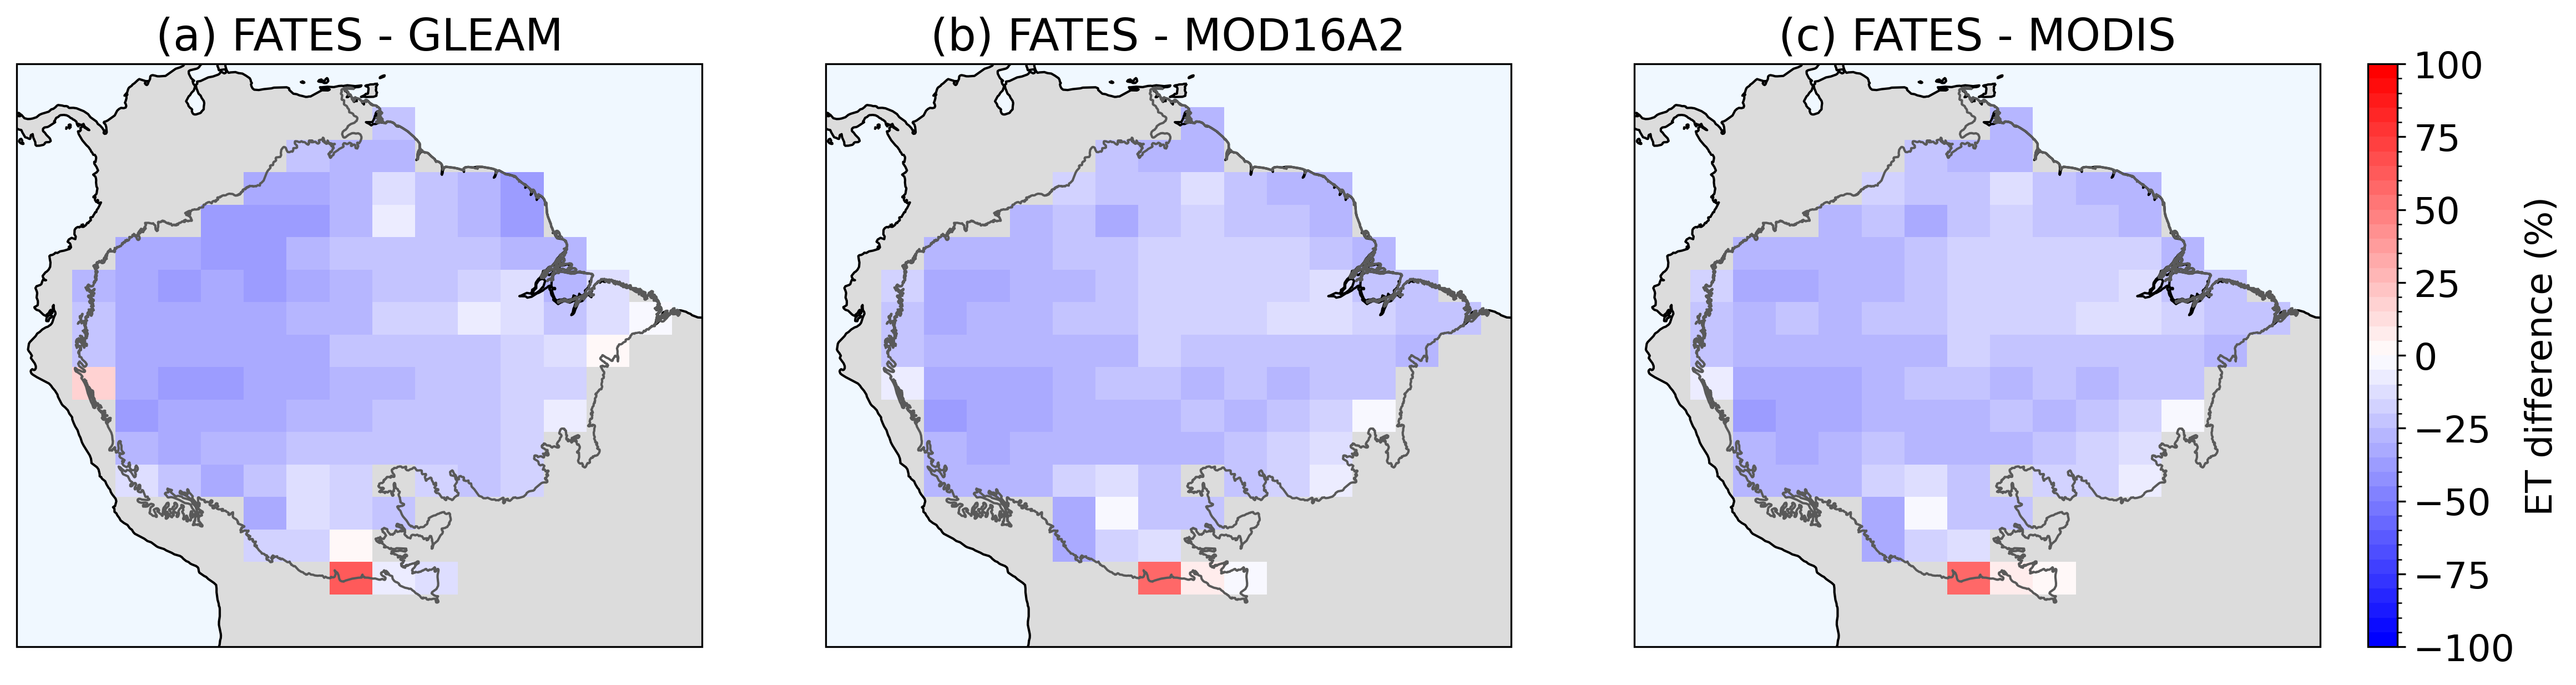

In [30]:
# Make a 3 panel figure for ET % differences

# Create figure with 3 subplots (1 row, 3 columns)
# Note: constrained_layout handles spacing; plt.tight_layout is removed.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3 = axes.flatten()

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - GLEAM)/GLEAM
gleam_diff = 100 * (fates_et - gleam_et) / gleam_et
im1 = gleam_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - GLEAM")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - MOD16A2)/MOD16A2
mod16a2_diff = 100 * (fates_et - mod16a2_et) / mod16a2_et
im2 = mod16a2_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - MOD16A2")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - MODIS)/MODIS
modis_diff = 100 * (fates_et - modis_et) / modis_et
im3 = modis_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - MODIS")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="vertical",
    shrink=1,
    pad=0.02,
    label="ET difference (%)",
)

In [39]:
## Print stats:
np.mean(modis_diff.et.where(fates_Amazon_mask > 0))


<xarray.DataArray 'et' ()>
array(-21.62851487)

In [40]:
np.std(modis_diff.et.where(fates_Amazon_mask > 0))

<xarray.DataArray 'et' ()>
array(10.2953744)

In [ ]:
# Latent heat flux
# Datasets: CLASS, DOLCE, FLUXCOM, WECANN

In [42]:
fates_lh=fates.EFLX_LH_TOT.mean(dim='time') #total latent heat flux [+ to atm]; W/m2

In [ ]:
class_lh=xr.open_dataset(in_path+'